Extra Features to improve the Accuracy of the Model/Prediction
1. Length of Question1
2. Length of Question2
3. Word Lentgh of Question1
4. Word Lentgh Of Question2
5. Common Words 
6. Total Words (words in q1 + words in q2)
7. Word Share (common words / total words)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
Quora_ques = pd.read_csv('train.csv')

In [3]:
df = Quora_ques.sample(30000,random_state=2)

In [4]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [ ]:
# Length of the Question1 and Question2
df['q1_len'] = df['question1'].apply(len)
df['q2_len'] = df['question2'].apply(len)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [19]:
# Word Length of Question1 and Question2

df['q1_word_len'] = df['question1'].str.split().apply(len)
df['q2_word_len'] = df['question2'].str.split().apply(len)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_word_len,q2_word_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [ ]:
import re

def word_common(row):
    q1_set = set(re.findall(r'\b\w+\b', row['question1'].lower()))
    q2_set = set(re.findall(r'\b\w+\b', row['question2'].lower()))
    return len(q1_set & q2_set)

In [31]:
df['Common_words_Count'] = df.apply(word_common,axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_word_len,q2_word_len,Common_words_Count
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,3
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [36]:
# Total Words

def word_total(row):
    q1_set = set(re.findall(r'\b\w+\b', row['question1'].lower()))
    q2_set = set(re.findall(r'\b\w+\b', row['question2'].lower()))
    return (len(q1_set) + len(q2_set))

In [38]:
df['Total_words_Count'] = df.apply(word_total,axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_word_len,q2_word_len,Common_words_Count,Total_words_Count
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,12,26
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,22
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,3,36
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [41]:
df['word_share'] = df['Common_words_Count']/df['Total_words_Count']
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_word_len,q2_word_len,Common_words_Count,Total_words_Count,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,12,26,0.461538
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,22,0.318182
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,3,36,0.083333
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.000000
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.230769


Minimum len: 2
Maximum len: 391
Average len: 59


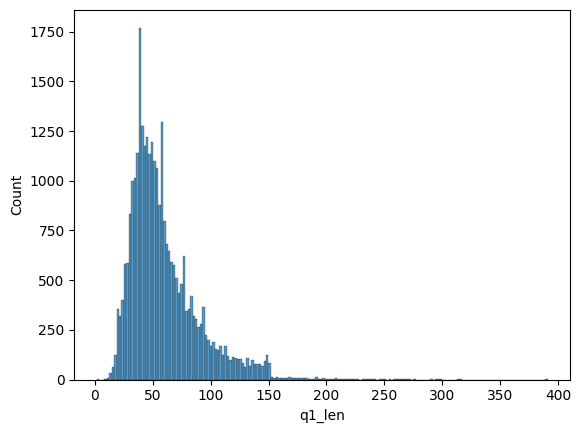

In [44]:
#Analysis of Features

sns.histplot(df['q1_len'])
print('Minimum len:',min(df['q1_len']))
print("Maximum len:",max(df['q1_len']))
print('Average len:',int(df['q1_len'].mean()))

Minimum len: 6
Maximum len: 1151
Average len: 60


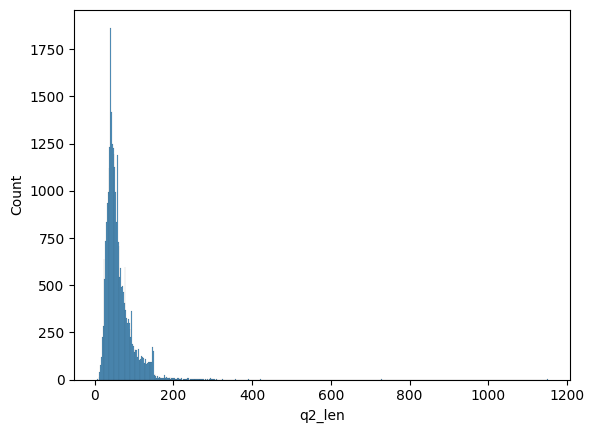

In [45]:
sns.histplot(df['q2_len'])
print('Minimum len:',min(df['q2_len']))
print("Maximum len:",max(df['q2_len']))
print('Average len:',int(df['q2_len'].mean()))

Minimum words: 1
Maximum words: 72
Average words: 10


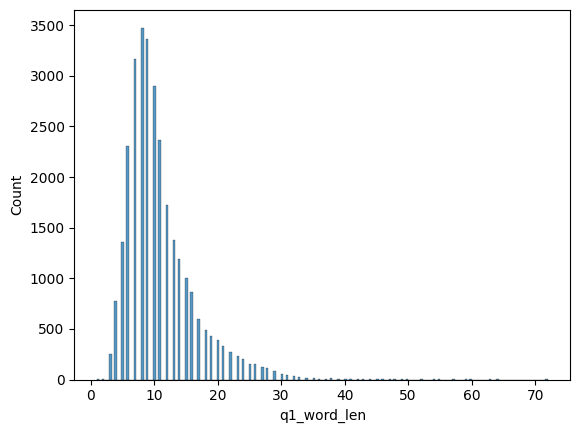

In [48]:
sns.histplot(df['q1_word_len'])
print('Minimum words:',min(df['q1_word_len']))
print("Maximum words:",max(df['q1_word_len']))
print('Average words:',int(df['q1_word_len'].mean()))

Minimum words: 1
Maximum words: 237
Average words: 11


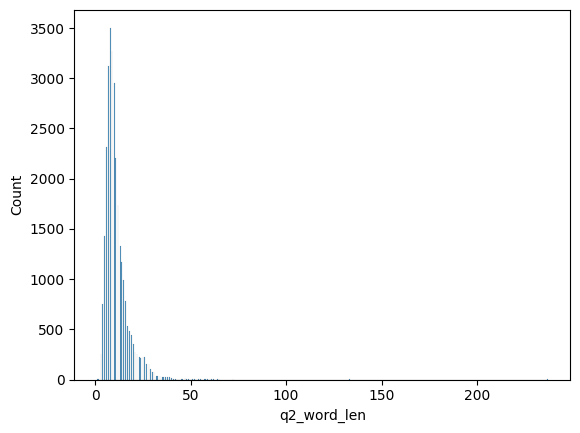

In [49]:
sns.histplot(df['q2_word_len'])
print('Minimum words:',min(df['q2_word_len']))
print("Maximum words:",max(df['q2_word_len']))
print('Average words:',int(df['q2_word_len'].mean()))

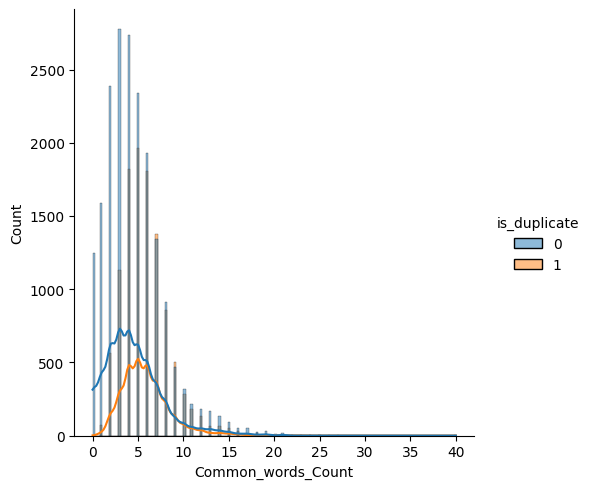

In [65]:
#Common Words

sns.displot(x=df['Common_words_Count'],kde=True,hue=df['is_duplicate'])


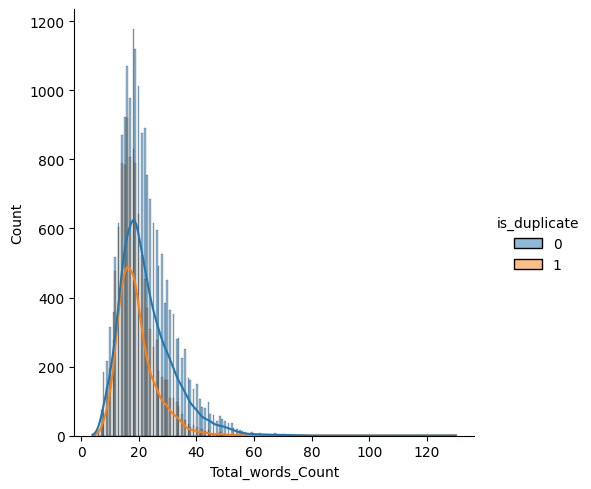

In [64]:
# Total words

sns.displot(x=df['Total_words_Count'],hue=df['is_duplicate'],kde=True)


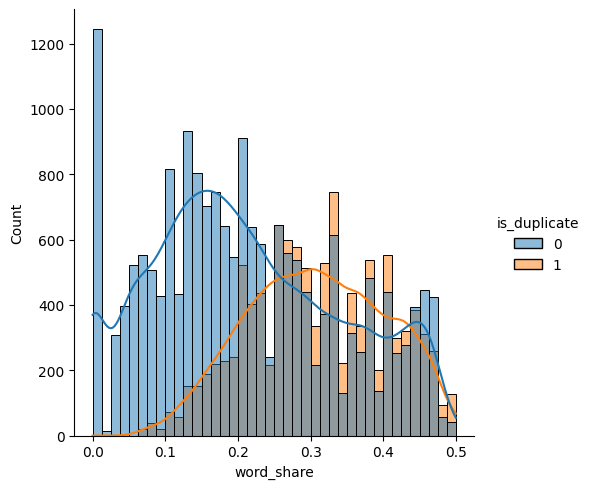

In [61]:
#Word share

sns.displot(x =df['word_share'],hue=df['is_duplicate'],kde=True)

In [83]:
final_df = df.drop(columns=['id','qid1','qid2','question1','question2'])
final_df.head()

,is_duplicate,q1_len,q2_len,q1_word_len,q2_word_len,Common_words_Count,Total_words_Count,word_share
398782,1,76,77,12,12,12,26,0.461538
115086,0,49,57,12,15,7,22,0.318182
327711,0,105,120,25,17,3,36,0.083333
367788,0,59,146,12,30,0,32,0.000000
151235,0,35,50,5,9,3,13,0.230769


In [74]:
ques_df = df[['question1','question2']]
from sklearn.feature_extraction.text import CountVectorizer

# merge text
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv =CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [77]:
temp_df1 = pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr,index=ques_df.index)
temp_df = pd.concat([temp_df1,temp_df2],axis=1)
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243932,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
91980,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
266955,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71112,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
final_df = pd.concat([final_df,temp_df],axis=1)
final_df

,is_duplicate,q1_len,q2_len,q1_word_len,q2_word_len,Common_words_Count,Total_words_Count,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,12,26,0.461538,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,22,0.318182,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,3,36,0.083333,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.000000,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.230769,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243932,1,42,41,7,7,6,14,0.428571,0,0,...,0,0,0,0,0,0,0,0,0,0
91980,0,68,61,12,12,4,25,0.160000,0,0,...,0,0,0,0,0,0,0,0,0,0
266955,0,73,98,14,17,6,30,0.200000,0,0,...,0,0,0,0,0,0,0,0,0,0
71112,1,51,45,10,10,5,20,0.250000,0,0,...,0,0,0,0,0,0,0,0,0,0


In [86]:
final_df.shape

(30000, 6008)

In [91]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.3,random_state=42)

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf =RandomForestClassifier()

rf.fit(X_train,y_train)

model = rf.predict(X_test)
print(accuracy_score(y_test,model))


0.761
